In [1]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv('../Datasets/Reviews.csv')
df['Summary'] = df['Summary'].fillna('')
df['Text'] = df['Text'].fillna('')
df['combined_text'] = df['Summary'] + ' ' + df['Text']

print("Dataset loaded! Shape:", df.shape)

Dataset loaded! Shape: (100000, 11)


In [3]:
# Filter active users
user_counts = df['UserId'].value_counts()
df_cf = df[df['UserId'].isin(user_counts[user_counts >= 10].index)]

# Build user product matrix
user_product_matrix = df_cf.pivot_table(
    index='UserId',
    columns='ProductId',
    values='Score'
).fillna(0)

# Calculate user similarity
user_similarity = cosine_similarity(user_product_matrix)

# Predict ratings
mean_user_rating = user_product_matrix.mean(axis=1)
ratings_diff = user_product_matrix.sub(mean_user_rating, axis=0)
cf_predictions = mean_user_rating.values[:, np.newaxis] + (
    user_similarity.dot(ratings_diff) /
    np.abs(user_similarity).sum(axis=1)[:, np.newaxis]
)
cf_pred_df = pd.DataFrame(
    cf_predictions,
    index=user_product_matrix.index,
    columns=user_product_matrix.columns
)

print("CF component ready!")

CF component ready!


In [4]:
# Group reviews by product
product_reviews = df.groupby('ProductId')['combined_text'].apply(
    lambda x: ' '.join(x)
).reset_index()

# TF-IDF
tfidf = TfidfVectorizer(max_features=5000, stop_words='english')
tfidf_matrix = tfidf.fit_transform(product_reviews['combined_text'])

# Product similarity
product_similarity = cosine_similarity(tfidf_matrix)
product_similarity_df = pd.DataFrame(
    product_similarity,
    index=product_reviews['ProductId'],
    columns=product_reviews['ProductId']
)

# Average score per product
avg_scores = df.groupby('ProductId')['Score'].mean()

print("CBF component ready!")

CBF component ready!


In [5]:
def hybrid_recommend(user_id, num_recommendations=5, alpha=0.5):
    # --- CF Part ---
    if user_id not in cf_pred_df.index:
        cf_scores = pd.Series(dtype=float)
    else:
        rated = user_product_matrix.loc[user_id]
        rated_products = rated[rated > 0].index.tolist()
        cf_scores = cf_pred_df.loc[user_id].drop(
            [p for p in rated_products if p in cf_pred_df.columns]
        )

    # --- CBF Part ---
    if user_id not in df['UserId'].values:
        cbf_scores = pd.Series(dtype=float)
    else:
        user_products = df[df['UserId'] == user_id]['ProductId'].tolist()
        cbf_scores = pd.Series(dtype=float)
        for product_id in user_products:
            if product_id in product_similarity_df.index:
                similar = product_similarity_df[product_id].drop(product_id)
                cbf_scores = pd.concat([cbf_scores, similar])
        cbf_scores = cbf_scores.groupby(cbf_scores.index).mean()

    # --- Combine Both ---
    all_products = set(cf_scores.index).union(set(cbf_scores.index))
    hybrid_scores = {}

    for product in all_products:
        cf_val = cf_scores.get(product, 0)
        cbf_val = cbf_scores.get(product, 0)
        hybrid_scores[product] = (alpha * cf_val) + ((1 - alpha) * cbf_val)

    # Sort and return top recommendations
    hybrid_series = pd.Series(hybrid_scores).nlargest(num_recommendations)

    print(f"Top {num_recommendations} Hybrid Recommendations for User: {user_id}")
    print(f"(Alpha: {alpha} → {int(alpha*100)}% CF + {int((1-alpha)*100)}% CBF)")
    print()
    for i, (pid, score) in enumerate(hybrid_series.items(), 1):
        print(f"{i}. Product: {pid} | Hybrid Score: {round(score, 2)}")

In [6]:
# Test with a sample user
sample_user = df_cf.index[0] if hasattr(df_cf, 'index') else df['UserId'].iloc[0]
sample_user = user_product_matrix.index[0]

hybrid_recommend(sample_user, num_recommendations=5, alpha=0.5)

Top 5 Hybrid Recommendations for User: A106ZCP7RSXMRU
(Alpha: 0.5 → 50% CF + 50% CBF)

1. Product: B001AHJ2D8 | Hybrid Score: 0.72
2. Product: B000EQX7CI | Hybrid Score: 0.54
3. Product: B001EO5R04 | Hybrid Score: 0.48
4. Product: B001E5E268 | Hybrid Score: 0.48
5. Product: B001EO5R0Y | Hybrid Score: 0.48


In [7]:
# Test different alpha values and compare MAE
alphas = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
mae_scores = []

actual_scores = []
for _, row in df_cf.iterrows():
    actual_scores.append(row['Score'])

for alpha in alphas:
    predicted = []
    for _, row in df_cf.iterrows():
        user = row['UserId']
        product = row['ProductId']
        cf_val = cf_pred_df.loc[user, product] if (
            user in cf_pred_df.index and product in cf_pred_df.columns
        ) else 0
        cbf_val = avg_scores.get(product, 0)
        hybrid_val = (alpha * cf_val) + ((1 - alpha) * cbf_val)
        predicted.append(hybrid_val)

    mae = mean_absolute_error(actual_scores, predicted)
    mae_scores.append(mae)
    print(f"Alpha: {alpha} → MAE: {round(mae, 4)}")

# Best alpha
best_alpha = alphas[mae_scores.index(min(mae_scores))]
print(f"\n✅ Best Alpha: {best_alpha} with MAE: {round(min(mae_scores), 4)}")

Alpha: 0.1 → MAE: 0.8748
Alpha: 0.2 → MAE: 1.015
Alpha: 0.3 → MAE: 1.1825
Alpha: 0.4 → MAE: 1.371
Alpha: 0.5 → MAE: 1.5773
Alpha: 0.6 → MAE: 1.7957
Alpha: 0.7 → MAE: 2.0239
Alpha: 0.8 → MAE: 2.2607
Alpha: 0.9 → MAE: 2.5079

✅ Best Alpha: 0.1 with MAE: 0.8748


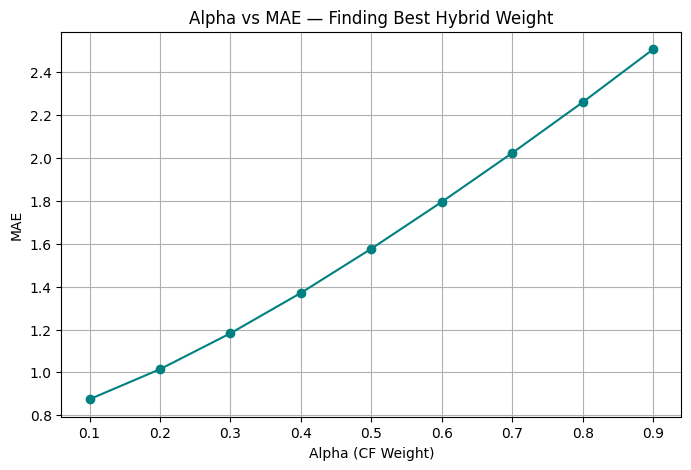

In [8]:
plt.figure(figsize=(8,5))
plt.plot(alphas, mae_scores, marker='o', color='teal')
plt.title('Alpha vs MAE — Finding Best Hybrid Weight')
plt.xlabel('Alpha (CF Weight)')
plt.ylabel('MAE')
plt.xticks(alphas)
plt.grid(True)
plt.show()

In [9]:
predicted_final = []
for _, row in df_cf.iterrows():
    user = row['UserId']
    product = row['ProductId']
    cf_val = cf_pred_df.loc[user, product] if (
        user in cf_pred_df.index and product in cf_pred_df.columns
    ) else 0
    cbf_val = avg_scores.get(product, 0)
    hybrid_val = (best_alpha * cf_val) + ((1 - best_alpha) * cbf_val)
    predicted_final.append(hybrid_val)

mae = mean_absolute_error(actual_scores, predicted_final)
mse = mean_squared_error(actual_scores, predicted_final)
r2 = r2_score(actual_scores, predicted_final)

print("=== Final Hybrid Model Scores ===")
print(f"Best Alpha : {best_alpha}")
print(f"MAE        : {round(mae, 4)}")
print(f"MSE        : {round(mse, 4)}")
print(f"R²         : {round(r2, 4)}")

=== Final Hybrid Model Scores ===
Best Alpha : 0.1
MAE        : 0.8748
MSE        : 1.1508
R²         : 0.1436


In [10]:
results = pd.DataFrame({
    'Model': ['Collaborative Filtering', 'Content Based Filtering', 'Hybrid Model'],
    'MAE':  [2.51, 0.83, round(mae, 4)],
    'MSE':  [8.88, 1.45, round(mse, 4)],
    'R²':   [-5.0, -0.45, round(r2, 4)]
})

print(results.to_string(index=False))

                  Model    MAE    MSE      R²
Collaborative Filtering 2.5100 8.8800 -5.0000
Content Based Filtering 0.8300 1.4500 -0.4500
           Hybrid Model 0.8748 1.1508  0.1436
